# Raport z laboratorium 2

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binom

## Zadanie 1

Nalezy dodac obliczenia mle do raportu. powinno wyjsc p = mean(x) / 5 mi wyszlo z -5 sprawdz pochodne

In [2]:
def mle(X):
    return np.mean(X) / 5

In [3]:
ns = [20, 50, 100]
ps = np.arange(0.1, 1, 0.2)
num_runs = 10000

results = {}
for n in ns:
    for p in ps:
        ppb_values = []
        for _ in range(num_runs):
            X = binom.rvs(5, p, size=n)
            p_mle = mle(X)

            ppb = binom.pmf(3, 5, p_mle) + binom.pmf(4, 5, p_mle) + binom.pmf(5, 5, p_mle)

            ppb_values.append(ppb)
        results[n, p] = ppb_values

In [11]:
mean = {}
var = {}
mse = {}
bias = {}
real_ppbs = {}
for (n, p), data in results.items():
    var[(n, p)] = np.var(data, ddof=1)
    real = binom.pmf(3, 5, p) + binom.pmf(4, 5, p) + binom.pmf(5, 5, p)
    real_ppbs[(n, p)] = real
    bias[(n, p)] = np.mean(data) - real
    mse[(n, p)] = var[(n, p)] + bias[(n, p)] ** 2

# Prepare data for plotting
plot_data = []
for n in ns:
    for p in ps:
        plot_data.append(
            {'n': n, 'p': p.round(2), 'real': real_ppbs[(n, p)], 'var': var[(n, p)], 'mse': mse[(n, p)], 'bias': bias[(n, p)]})

plot_df = pd.DataFrame(plot_data)
print(plot_df)


      n    p     real       var       mse      bias
0    20  0.1  0.00856  0.000074  0.000078  0.001890
1    20  0.3  0.16308  0.003686  0.003712  0.005122
2    20  0.5  0.50000  0.008539  0.008539  0.000525
3    20  0.7  0.83692  0.003705  0.003735 -0.005466
4    20  0.9  0.99144  0.000075  0.000080 -0.002098
5    50  0.1  0.00856  0.000024  0.000025  0.000798
6    50  0.3  0.16308  0.001475  0.001477  0.001549
7    50  0.5  0.50000  0.003477  0.003478 -0.000797
8    50  0.7  0.83692  0.001444  0.001454 -0.003116
9    50  0.9  0.99144  0.000024  0.000025 -0.000775
10  100  0.1  0.00856  0.000012  0.000012  0.000397
11  100  0.3  0.16308  0.000710  0.000711  0.001116
12  100  0.5  0.50000  0.001732  0.001732 -0.000480
13  100  0.7  0.83692  0.000739  0.000742 -0.001498
14  100  0.9  0.99144  0.000011  0.000011 -0.000364


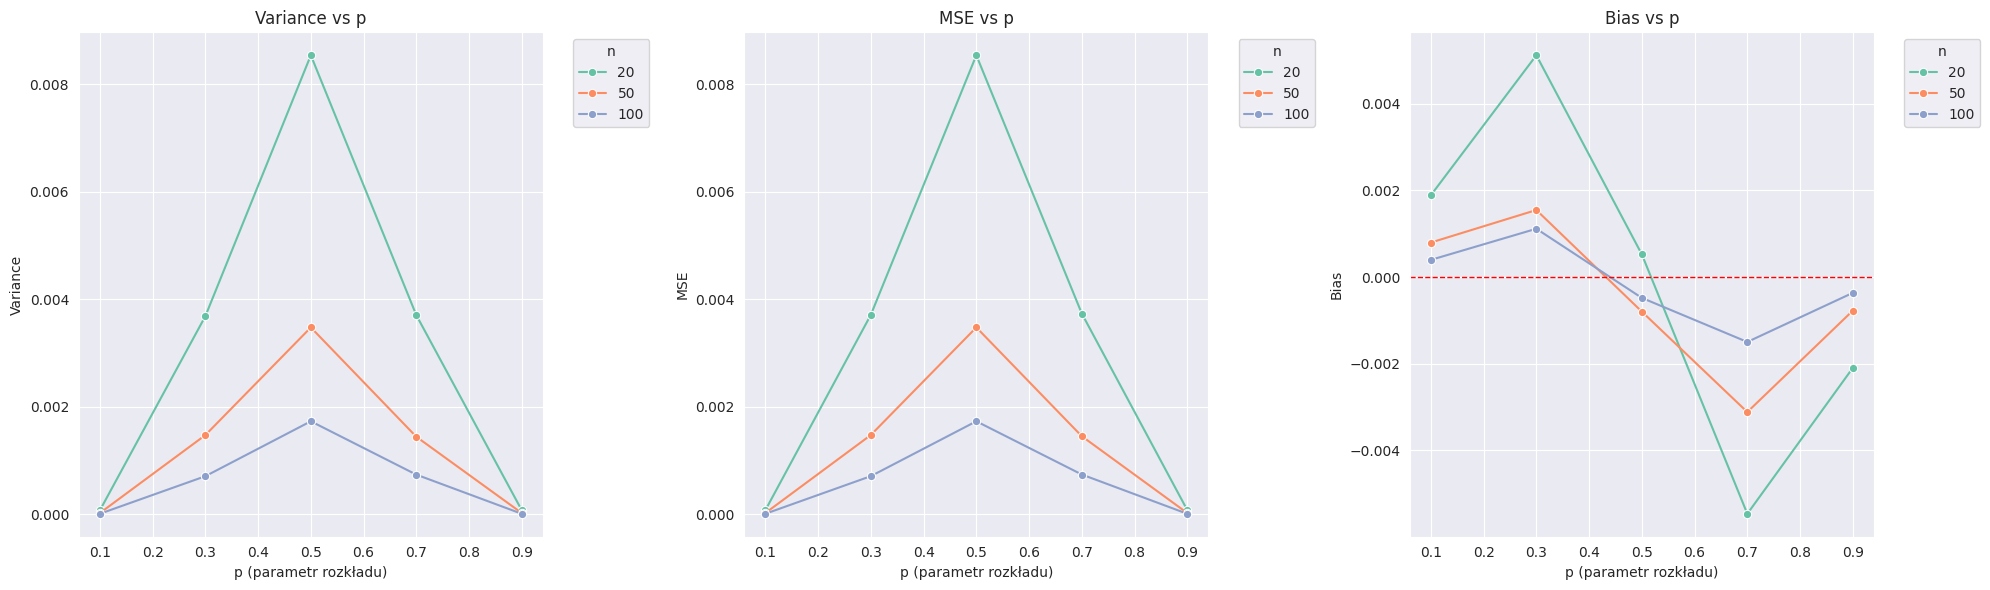

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Variance vs p dla każdego n
sns.lineplot(data=plot_df, x='p', y='var', hue='n', marker='o', ax=axes[0], palette='Set2')
axes[0].set_title('Variance vs p')
axes[0].set_xlabel('p (parametr rozkładu)')
axes[0].set_ylabel('Variance')
axes[0].legend(title='n', bbox_to_anchor=(1.05, 1), loc='upper left')

# MSE vs p dla każdego n
sns.lineplot(data=plot_df, x='p', y='mse', hue='n', marker='o', ax=axes[1], palette='Set2')
axes[1].set_title('MSE vs p')
axes[1].set_xlabel('p (parametr rozkładu)')
axes[1].set_ylabel('MSE')
axes[1].legend(title='n', bbox_to_anchor=(1.05, 1), loc='upper left')

# Bias vs p dla każdego n
sns.lineplot(data=plot_df, x='p', y='bias', hue='n', marker='o', ax=axes[2], palette='Set2')
axes[2].set_title('Bias vs p')
axes[2].set_xlabel('p (parametr rozkładu)')
axes[2].set_ylabel('Bias')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].legend(title='n', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

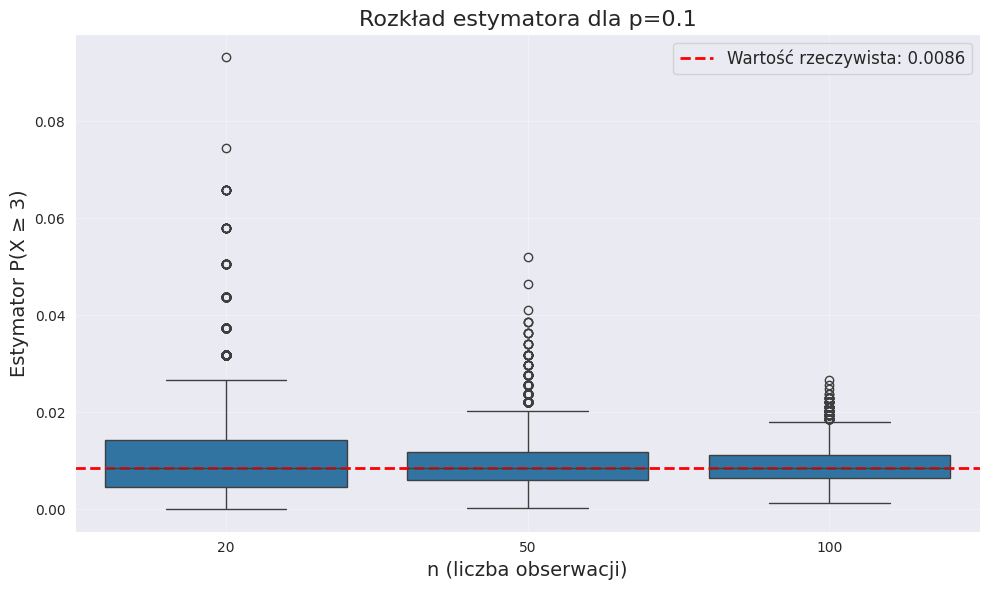

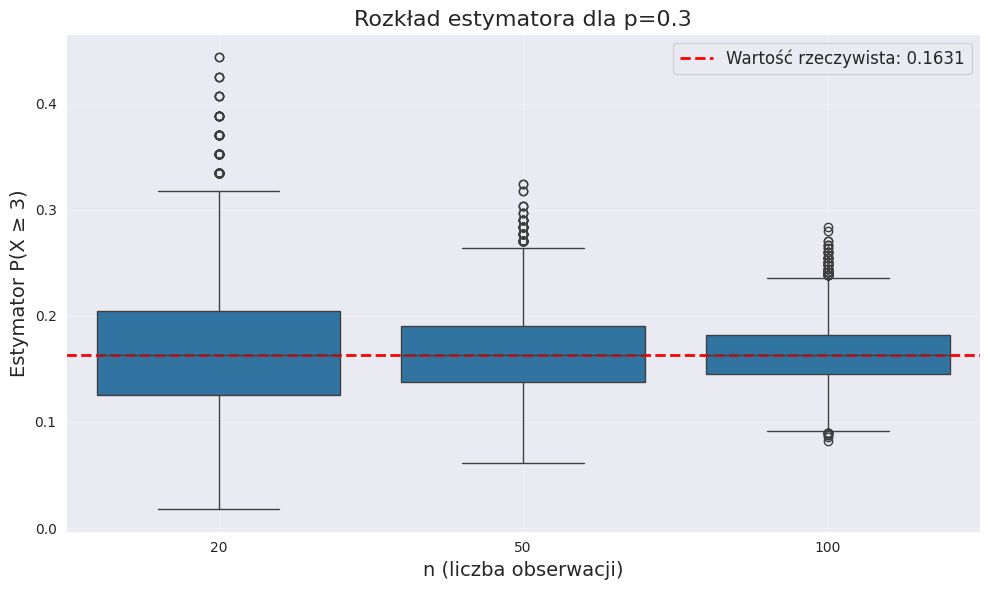

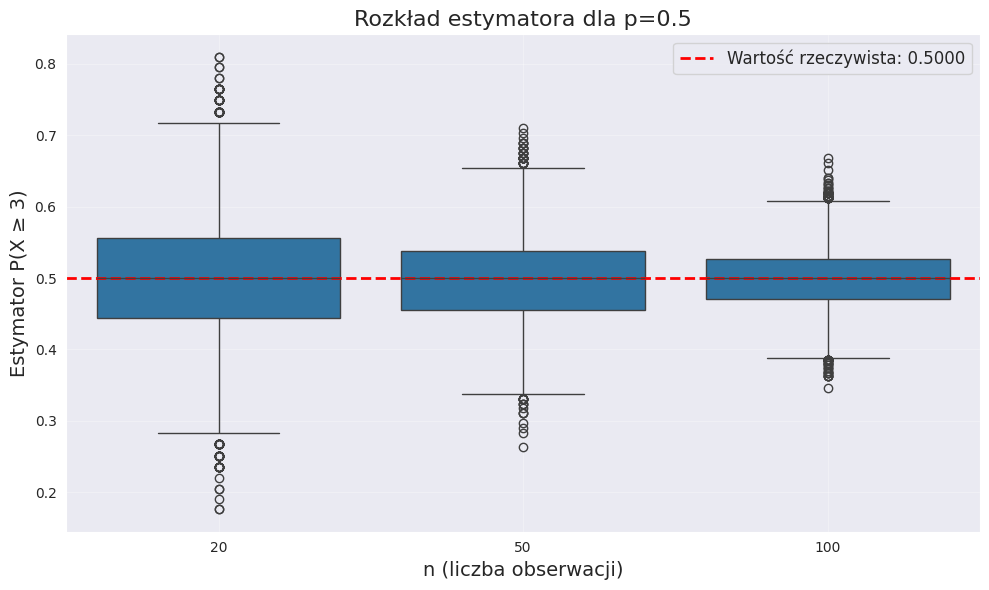

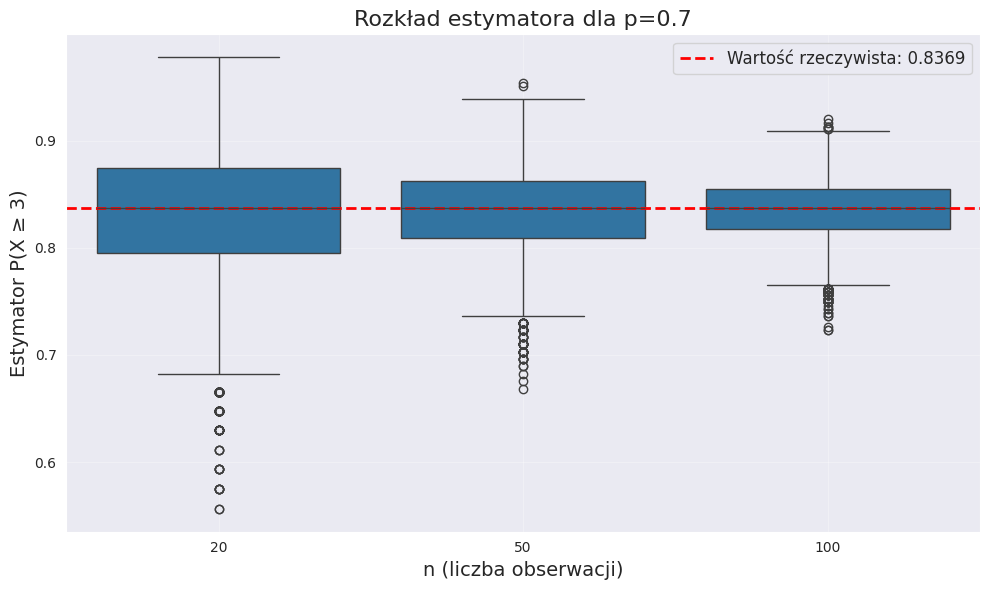

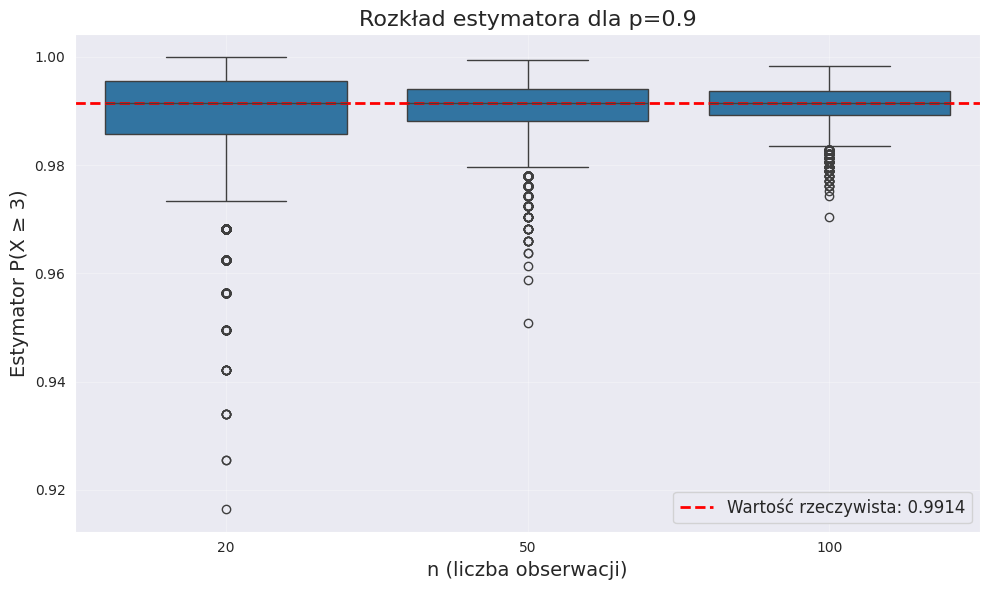

In [23]:
# Przygotowanie danych do boxplotów
boxplot_data = []
for (n, p), data in results.items():
    for value in data:
        boxplot_data.append({'n': n, 'p': round(p, 2), 'ppb_estimate': value})

boxplot_df = pd.DataFrame(boxplot_data)

# Tworzenie osobnych wykresów dla każdej wartości p
for p_val in ps:
    p_rounded = round(p_val, 2)
    subset = boxplot_df[boxplot_df['p'] == p_rounded]

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(data=subset, x='n', y='ppb_estimate', ax=ax)
    ax.set_title(f'Rozkład estymatora dla p={p_rounded}', fontsize=16)
    ax.set_xlabel('n (liczba obserwacji)', fontsize=14)
    ax.set_ylabel('Estymator P(X ≥ 3)', fontsize=14)

    # Dodaj teoretyczną wartość
    real_val = binom.pmf(3, 5, p_val) + binom.pmf(4, 5, p_val) + binom.pmf(5, 5, p_val)
    ax.axhline(real_val, color='red', linestyle='--', linewidth=2,
               label=f'Wartość rzeczywista: {real_val:.4f}')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Zadanie 2